
Sales Performance Summary:
           Period  Total Sales Volume Total Revenue Total Profit
Jan 2024 (Before)                 125       $987.00      $575.80
Jun 2024 (Before)                 408     $5,227.00    $3,000.63
 Dec 2023 (After)                 968    $13,552.00    $7,521.36
 Jul 2024 (After)                 836    $11,704.00    $6,495.72


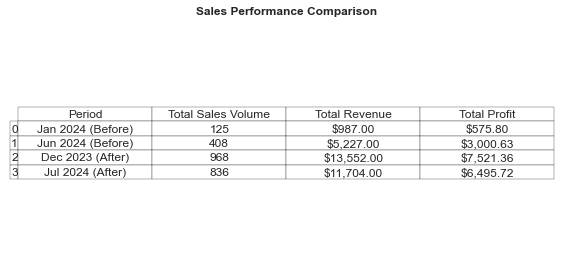

ANALYSIS RESULTS

Monthly Totals:
Jan 2024 (Before):
  Revenue: $987.00
  Profit: $575.80
Jun 2024 (Before):
  Revenue: $5,227.00
  Profit: $3,000.63
Dec 2023 (After):
  Revenue: $13,552.00
  Profit: $7,521.36
Jul 2024 (After):
  Revenue: $11,704.00
  Profit: $6,495.72

Profit Margins:
Fizzi (Individual): 65.5%
8PCR (Individual): 57.4%
Bundle: 55.5%

Growth Analysis:
Revenue Growth (Dec vs Jan): 1273.0%
Profit Growth (Dec vs Jan): 1206.2%
Revenue Growth (Jul vs Jun): 123.9%
Profit Growth (Jul vs Jun): 116.5%

Total Impact:
Combined Revenue Growth: 306.4%


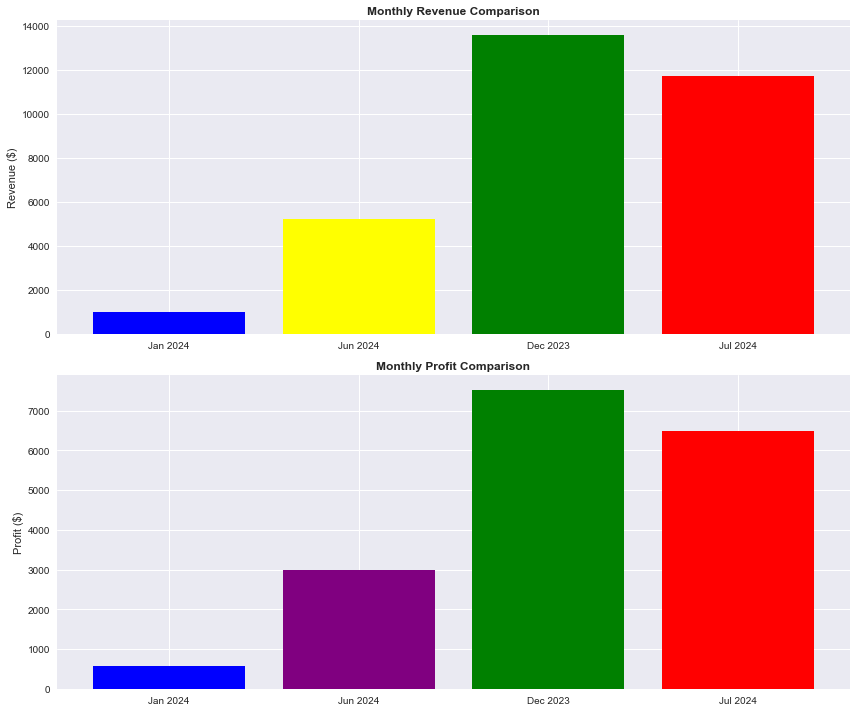

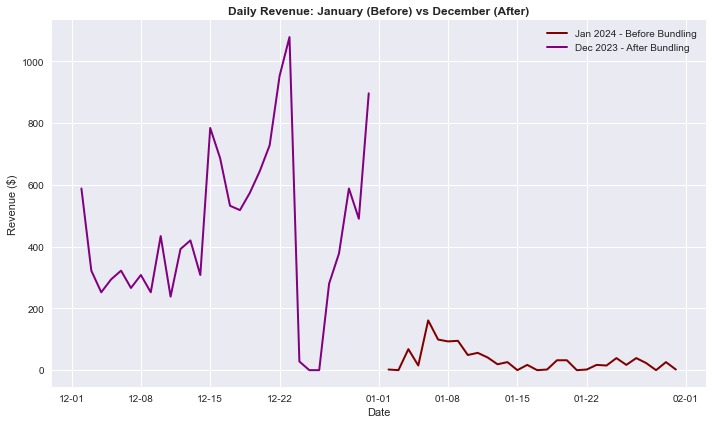

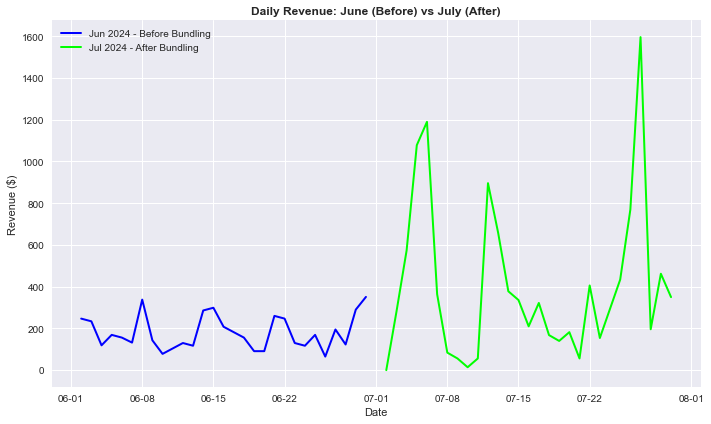

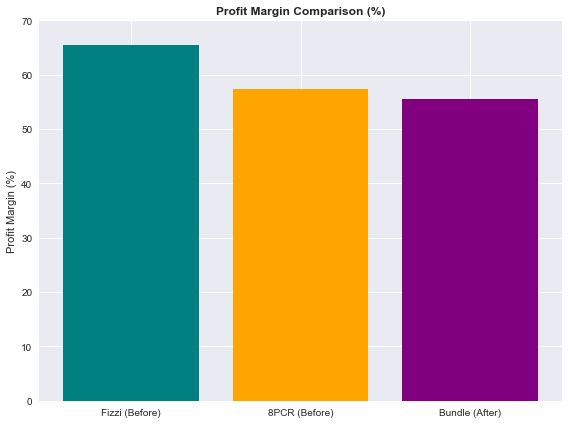

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter

# Set style for plots
plt.style.use('seaborn')

# Load and preprocess data
def load_data():
    # Load data with headers
    individual = pd.read_excel(r"C:\Users\mlule\Desktop\BEFORE AND AFTER BUNDLING (NOTHANDO).xlsx", 
                             sheet_name='INDIVIDUAL SALES', header=1)
    bundled = pd.read_excel(r"C:\Users\mlule\Desktop\BEFORE AND AFTER BUNDLING (NOTHANDO).xlsx", 
                           sheet_name='BUNDLED 2LTR FIZZI+8PCR', header=1)
    
    # Process individual sales (exclude last "total" row)
    jan = process_individual(individual.iloc[0:30, 0:7].copy(), 'Jan')  # January data
    jun = process_individual(individual.iloc[0:29, 8:15].copy(), 'Jun') # June data
    
    # Process bundled sales
    dec = process_bundled(bundled.iloc[0:30, 0:4].copy(), 'Dec')  # December data
    jul = process_bundled(bundled.iloc[0:29, 5:9].copy(), 'Jul')  # July data
    
    return jan, jun, dec, jul

def process_individual(df, month):
    # Clean column names and convert data types
    df.columns = ['date', 'fizzi_qty', 'fizzi_price', 'fizzi_cost', 
                 'pcr8_qty', 'pcr8_price', 'pcr8_cost']
    
    # Convert dates and handle errors
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date'])
    
    # Convert quantities to numeric
    df['fizzi_qty'] = pd.to_numeric(df['fizzi_qty'], errors='coerce')
    df['pcr8_qty'] = pd.to_numeric(df['pcr8_qty'], errors='coerce')
    
    # Calculate financial metrics
    df['total_revenue'] = (df['fizzi_qty'] * df['fizzi_price']) + (df['pcr8_qty'] * df['pcr8_price'])
    df['total_cost'] = (df['fizzi_qty'] * df['fizzi_cost']) + (df['pcr8_qty'] * df['pcr8_cost'])
    df['total_profit'] = df['total_revenue'] - df['total_cost']
    
    return df.dropna()

def process_bundled(df, month):
    # Clean column names
    df.columns = ['date', 'bundle_qty', 'bundle_price', 'bundle_cost']
    
    # Convert dates and handle errors
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date'])
    
    # Convert quantities to numeric
    df['bundle_qty'] = pd.to_numeric(df['bundle_qty'], errors='coerce')
    
    # Calculate financial metrics
    df['bundle_revenue'] = df['bundle_qty'] * df['bundle_price']
    df['bundle_profit'] = df['bundle_revenue'] - (df['bundle_qty'] * df['bundle_cost'])
    
    return df.dropna()


# Main execution
if __name__ == "__main__":
    # Load processed data
    jan_df, jun_df, dec_df, jul_df = load_data()
    
    # Calculate key metrics
    metrics = {
        'Jan 2024 (Before)': {
            'Total Sales Volume': jan_df['fizzi_qty'].sum() + jan_df['pcr8_qty'].sum(),
            'Total Revenue': jan_df['total_revenue'].sum(),
            'Total Profit': jan_df['total_profit'].sum()
        },
        'Jun 2024 (Before)': {
            'Total Sales Volume': jun_df['fizzi_qty'].sum() + jun_df['pcr8_qty'].sum(),
            'Total Revenue': jun_df['total_revenue'].sum(),
            'Total Profit': jun_df['total_profit'].sum()
        },
        'Dec 2023 (After)': {
            'Total Sales Volume': dec_df['bundle_qty'].sum(),
            'Total Revenue': dec_df['bundle_revenue'].sum(),
            'Total Profit': dec_df['bundle_profit'].sum()
        },
        'Jul 2024 (After)': {
            'Total Sales Volume': jul_df['bundle_qty'].sum(),
            'Total Revenue': jul_df['bundle_revenue'].sum(),
            'Total Profit': jul_df['bundle_profit'].sum()
        }
    }

    # Create results table
    results_df = pd.DataFrame.from_dict(metrics, orient='index')
    results_df = results_df.reset_index().rename(columns={'index': 'Period'})
    
    # Format numerical values
    results_df['Total Sales Volume'] = results_df['Total Sales Volume'].astype(int)
    results_df['Total Revenue'] = results_df['Total Revenue'].map("${:,.2f}".format)
    results_df['Total Profit'] = results_df['Total Profit'].map("${:,.2f}".format)

    # Print results table
    print("\nSales Performance Summary:")
    print(results_df.to_string(index=False))
    
    # Create styled table visualization
    plt.figure(figsize=(10, 4))
    ax = plt.subplot(111, frame_on=False)
    ax.xaxis.set_visible(False)
    ax.yaxis.set_visible(False)
    
    table = pd.plotting.table(ax, results_df, 
                            loc='center', 
                            cellLoc='center',
                            colWidths=[0.2]*len(results_df.columns))
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 1.2)
    plt.title("Sales Performance Comparison", pad=20, weight='bold')
    plt.savefig('performance_table.png', bbox_inches='tight')
    plt.show()

  
    # Print calculated results
    print("="*50)
    print("ANALYSIS RESULTS")
    print("="*50)
    
    # 1. Monthly Totals
    print("\nMonthly Totals:")
    for period, values in metrics.items():
        print(f"{period}:")
        print(f"  Revenue: ${values['Total Revenue']:,.2f}")
        print(f"  Profit: ${values['Total Profit']:,.2f}")
    
    # 2. Profit Margins
    fizzi_margin = ((2 - 0.69)/2 * 100)
    pcr8_margin = ((13 - 5.54)/13 * 100)
    bundle_margin = ((14 - 6.23)/14 * 100)
    
    print("\nProfit Margins:")
    print(f"Fizzi (Individual): {fizzi_margin:.1f}%")
    print(f"8PCR (Individual): {pcr8_margin:.1f}%")
    print(f"Bundle: {bundle_margin:.1f}%")
    
    # 3. Growth Analysis
    def calculate_growth(before, after):
        return ((after - before)/before * 100)
    
    # December vs January growth
    rev_growth_dec_jan = calculate_growth(metrics['Jan 2024 (Before)']['Total Revenue'], 
                                        metrics['Dec 2023 (After)']['Total Revenue'])
    profit_growth_dec_jan = calculate_growth(metrics['Jan 2024 (Before)']['Total Profit'], 
                                           metrics['Dec 2023 (After)']['Total Profit'])
    
    # July vs June growth
    rev_growth_jul_jun = calculate_growth(metrics['Jun 2024 (Before)']['Total Revenue'], 
                                        metrics['Jul 2024 (After)']['Total Revenue'])
    profit_growth_jul_jun = calculate_growth(metrics['Jun 2024 (Before)']['Total Profit'], 
                                           metrics['Jul 2024 (After)']['Total Profit'])
    
    print("\nGrowth Analysis:")
    print(f"Revenue Growth (Dec vs Jan): {rev_growth_dec_jan:.1f}%")
    print(f"Profit Growth (Dec vs Jan): {profit_growth_dec_jan:.1f}%")
    print(f"Revenue Growth (Jul vs Jun): {rev_growth_jul_jun:.1f}%")
    print(f"Profit Growth (Jul vs Jun): {profit_growth_jul_jun:.1f}%")
    
    # 4. Total Impact
    total_before_rev = metrics['Jan 2024 (Before)']['Total Revenue'] + metrics['Jun 2024 (Before)']['Total Revenue']
    total_after_rev = metrics['Dec 2023 (After)']['Total Revenue'] + metrics['Jul 2024 (After)']['Total Revenue']
    total_rev_growth = calculate_growth(total_before_rev, total_after_rev)
    
    print("\nTotal Impact:")
    print(f"Combined Revenue Growth: {total_rev_growth:.1f}%")
    print("="*50)


# Visualization 1: Monthly Revenue and Profit Comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
months = ['Jan 2024', 'Jun 2024', 'Dec 2023', 'Jul 2024']

# Revenue plot
revenues = [metrics[m]['Total Revenue'] for m in metrics]
ax1.bar(months, revenues, color=['blue', 'yellow', 'green', 'red'])
ax1.set_title('Monthly Revenue Comparison', weight='bold')
ax1.set_ylabel('Revenue ($)')
ax1.grid(True, axis='y')

# Profit plot
profits = [metrics[m]['Total Profit'] for m in metrics]
ax2.bar(months, profits, color=['blue', 'purple', 'green', 'red'])
ax2.set_title('Monthly Profit Comparison', weight='bold')
ax2.set_ylabel('Profit ($)')
ax2.grid(True, axis='y')

plt.tight_layout()
plt.savefig('monthly_comparison.png')
plt.show()

# Visualization 2: January vs December Comparison
plt.figure(figsize=(10, 6))
plt.plot(jan_df['date'], jan_df['total_revenue'], 
         label='Jan 2024 - Before Bundling', color='maroon', linewidth=2)
plt.plot(dec_df['date'], dec_df['bundle_revenue'], 
         label='Dec 2023 - After Bundling', color='purple', linewidth=2)
plt.title('Daily Revenue: January (Before) vs December (After)', weight='bold')
plt.xlabel('Date')
plt.ylabel('Revenue ($)')
plt.legend()
plt.gca().xaxis.set_major_formatter(DateFormatter("%m-%d"))
plt.grid(True)
plt.tight_layout()
plt.savefig('jan_vs_dec_revenue.png')
plt.show()

# Visualization 3: June vs July Comparison
plt.figure(figsize=(10, 6))
plt.plot(jun_df['date'], jun_df['total_revenue'], 
         label='Jun 2024 - Before Bundling', color='blue', linewidth=2)
plt.plot(jul_df['date'], jul_df['bundle_revenue'], 
         label='Jul 2024 - After Bundling', color='lime', linewidth=2)
plt.title('Daily Revenue: June (Before) vs July (After)', weight='bold')
plt.xlabel('Date')
plt.ylabel('Revenue ($)')
plt.legend()
plt.gca().xaxis.set_major_formatter(DateFormatter("%m-%d"))
plt.grid(True)
plt.tight_layout()
plt.savefig('jun_vs_jul_revenue.png')
plt.show()

# Visualization 4: Profit Margin Comparison
profit_margins = {
    'Fizzi (Before)': ((2 - 0.69)/2 * 100),
    '8PCR (Before)': ((13 - 5.54)/13 * 100),
    'Bundle (After)': ((14 - 6.23)/14 * 100)
}

plt.figure(figsize=(8, 6))
plt.bar(profit_margins.keys(), profit_margins.values(), 
        color=['teal', 'orange', 'purple'])
plt.title('Profit Margin Comparison (%)', weight='bold')
plt.ylabel('Profit Margin (%)')
plt.ylim(0, 70)
plt.grid(True, axis='y')
plt.tight_layout()
plt.savefig('profit_margin_comparison.png')
plt.show()

In [12]:
jun_df

,date,fizzi_qty,fizzi_price,fizzi_cost,pcr8_qty,pcr8_price,pcr8_cost,total_revenue,total_cost,total_profit
0,2024-06-02,0.0,2.0,0.69,19.0,13.0,5.54,247.0,105.26,141.74
1,2024-06-03,0.0,2.0,0.69,18.0,13.0,5.54,234.0,99.72,134.28
2,2024-06-04,1.0,2.0,0.69,9.0,13.0,5.54,119.0,50.55,68.45
3,2024-06-05,0.0,2.0,0.69,13.0,13.0,5.54,169.0,72.02,96.98
4,2024-06-06,0.0,2.0,0.69,12.0,13.0,5.54,156.0,66.48,89.52
5,2024-06-07,1.0,2.0,0.69,10.0,13.0,5.54,132.0,56.09,75.91
6,2024-06-08,0.0,2.0,0.69,26.0,13.0,5.54,338.0,144.04,193.96
7,2024-06-09,0.0,2.0,0.69,11.0,13.0,5.54,143.0,60.94,82.06
8,2024-06-10,0.0,2.0,0.69,6.0,13.0,5.54,78.0,33.24,44.76
9,2024-06-11,0.0,2.0,0.69,8.0,13.0,5.54,104.0,44.32,59.68
